In [70]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
import warnings
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

root        = '../'
data_file   = '03_data/data_for_experiments/'
output_file = '05_output/'
start_date  = '200101'
end_date    = '202412'

os.makedirs(root + output_file, exist_ok=True)

temp_dir = "D:/github_repositories"
os.makedirs(temp_dir, exist_ok=True)

# 强制覆盖环境变量
os.environ["TEMP"] = temp_dir
os.environ["TMP"] = temp_dir
os.environ["JOBLIB_TEMP_FOLDER"] = temp_dir # 专门针对 joblib

In [71]:
# # creat small data samples
# root        = '../'
# data_file   = '03_data/'

# all_signals = pd.read_parquet(root + data_file + 'WRDS/all_signals.parquet')
# all_signals.rename(columns={'yyyymm': 'date'}, inplace=True)
# all_signals['date'] = all_signals['date'].astype(str)
# all_signals = all_signals[(all_signals['date'] >= start_date) & (all_signals['date'] <= end_date)]
# os.makedirs(root + data_file + 'data_for_experiments/', exist_ok=True)
# all_signals.to_pickle(root + data_file + 'data_for_experiments/all_signals.pickle')
# del all_signals
# print('signals done')

# crsp_d = pd.read_parquet(root + data_file + 'WRDS/crsp_d.parquet')
# crsp_d = crsp_d[(crsp_d['date'] >= start_date[:4] + '-' + start_date[4:] + '-01') & (crsp_d['date'] <= end_date[:4] + '-' + end_date[4:] + '-31')]
# crsp_d.reset_index(drop=True, inplace=True)
# crsp_d.to_pickle(root + data_file + 'data_for_experiments/stock_daily.pickle')
# del crsp_d
# print('stock done')

In [72]:
# # generate monthly return data from daily return
# stock_daily = pd.read_pickle(root + data_file + 'stock_daily.pickle')
# stock_daily['month'] = stock_daily['date'].apply(lambda x: x[:7])
# stock_daily.sort_values(by=['permno', 'date'], inplace=True)
# stock_monthly = stock_daily.groupby(['permno', 'month']).agg(
#     ret       = ('ret',    'sum'),
#     prc       = ('prc',    'last'),
#     shrout    = ('shrout', 'last'),
#     vol       = ('vol',    'sum'),
#     shrcd     = ('shrcd',  'last'),
#     exchcd    = ('exchcd', 'last'),
# ).reset_index()
# stock_monthly['date'] = stock_monthly['month'].apply(lambda x: x.split('-')[0] + x.split('-')[1])
# stock_monthly = stock_monthly[['permno', 'date', 'ret', 'prc', 'shrout', 'vol', 'shrcd', 'exchcd']]
# os.makedirs(root + output_file + 'stock_monthly/', exist_ok=True)
# stock_monthly.to_pickle(root + output_file + 'stock_monthly/stock_monthly.pickle')

In [73]:
# import wrds
# db = wrds.Connection(wrds_username = 'dunran')
# sp500list = db.raw_sql("SELECT * FROM crsp.dsp500list")

In [74]:
signal_doc = pd.read_csv(root + '03_data/SignalDoc.csv')
signal_doc['Filter'] = signal_doc['Filter'].fillna('0')
signal_list = signal_doc[
    (signal_doc['Predictability in OP'] == '1_clear')
    & (signal_doc['Signal Rep Quality'] == '1_good')
    & (signal_doc['Cat.Form'] == 'continuous')
]['Acronym'].tolist()

signals = pd.read_pickle(root + data_file + 'all_signals.pickle')
signals = signals[['permno', 'date'] + signal_list]

nan_pct = signals.isnull().mean()
nan_pct = nan_pct[nan_pct < 0.3]
signals = signals[(list(nan_pct.index))]

In [75]:
stock_monthly = pd.read_pickle(root + output_file + 'stock_monthly/stock_monthly.pickle')
stock_monthly = stock_monthly[(stock_monthly['prc'] >= 5)]
stock_monthly = stock_monthly.merge(
    right = signals,
    on    = ['permno', 'date'],
    how   = 'left',
).dropna()

In [76]:
def Equal_Weighted(returns_array, c):
    n_stocks = returns_array.shape[1]
    if c == True:
        weight = np.zeros((n_stocks, 1))
        weight[0, 0] = 1
    else:
        weight = 1.0 / n_stocks
        weight = np.full((n_stocks, 1), weight)
    return weight

def DRMV(returns, delta = 0.1, p = 2):
    n, d = returns.shape
    mu = np.mean(returns, axis=0)
    Sigma = returns.T @ returns / n
    V = Sigma - np.outer(mu, mu)
    V += np.eye(V.shape[0]) * 1e-9
    
    def objective(phi):
        return float(np.sqrt(phi.T @ V @ phi) + np.sqrt(delta) * np.linalg.norm(phi, ord=p))
    
    cons = [
        {'type': 'eq',   'fun': lambda phi: np.sum(phi) - 1.0},
    ]
    
    res = minimize(objective, x0=np.ones(d)/d, method='SLSQP', constraints=cons,
        options={'disp': False, 'maxiter': 500, 'ftol': 1e-9},
        tol=1e-9
    )
    
    weights = res.x.reshape(-1, 1)
    weights = weights / np.sum(weights)
    return weights


def DRMV_socp(returns, delta, p, c):
    n, d = returns.shape
    mu = np.mean(returns, axis=0).reshape(-1, 1)
    Sigma = returns.T @ returns / n
    V = Sigma - mu @ mu.T
    V += np.eye(V.shape[0]) * 1e-9
    L = np.linalg.cholesky(V)

    phi = cp.Variable((d, 1))
    objective = cp.Minimize(cp.norm(L.T @ phi) + cp.sqrt(delta) * cp.norm(phi, p))
    if c == True:
        constraints = [phi[0] == 1]
    else:
        constraints = [cp.sum(phi) == 1]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, verbose=False)
    weights = phi.value
    return weights.reshape(-1, 1)

In [77]:
# from joblib import Parallel, delayed
# from tqdm.auto import tqdm

# def _single_iter(data, T, N, strategy_num, s):
#     rng = np.random.default_rng(45 + s)
#     data_cut = data[:, rng.permutation(data.shape[1])[:N]]
#     T_steps = data_cut.shape[0] - T - 1
#     ret = np.zeros((strategy_num, T_steps))

#     for i in range(T_steps):
#         train = data_cut[i:i+T, :]
#         test  = data_cut[i+T+1, :]

#         w = []
#         w.append(Equal_Weighted(train).flatten())
#         for j in range(1, strategy_num - 1):
#             w.append(DRMV_socp(train, 10**(-j+1)).flatten())
#         w.append(DRMV_socp(train, 0).flatten())

#         for j, weight in enumerate(w):
#             ret[j, i] = test @ weight
        
#     return ret


# def evaluate_parallel(data, T, N, iter_num, strategy_num, n_jobs=-1):
#     with Parallel(n_jobs=n_jobs, prefer='processes') as parallel:
#         results = parallel(
#             delayed(_single_iter)(data, T, N, strategy_num, s) 
#             for s in tqdm(range(iter_num), desc=f"N={N}")
#         )
    
#     port_ret = np.stack(results, axis=1)
#     return port_ret

In [78]:
def fast_pivot_3d(df, index_col, columns_col, value_cols):
    row_idx = pd.Categorical(df[index_col], ordered=True)
    col_idx = pd.Categorical(df[columns_col], ordered=True)
    
    n_rows = len(row_idx.categories)
    n_cols = len(col_idx.categories)
    n_feats = len(value_cols)
    
    out = np.full((n_rows, n_cols, n_feats), np.nan)
    out[row_idx.codes, col_idx.codes, :] = df[value_cols].values
    
    return out.transpose([0, 2, 1]), row_idx.categories, col_idx.categories

data, dates, permnos = fast_pivot_3d(stock_monthly, 'date', 'permno', ['ret']+list(stock_monthly.columns[9:]))
data = data[24:-7, :, :]
data = data[:, :, (np.isnan(data).sum(axis=(0, 1))==0)]

In [79]:
data.shape

(252, 19, 916)

In [ ]:
from joblib import Parallel, delayed
from tqdm.auto import tqdm

def _single_iter(data, T, N, strategy_num, c, s):
    rng = np.random.default_rng(45 + s)
    rsl = rng.permutation(data.shape[2])[:N]
    ret_data_cut = data[:, :1, rsl]
    if c == True:
        sig_data_cut = data[:, 1:, rsl]
        if N > 1:
            sig_data_cut = (sig_data_cut - np.mean(sig_data_cut, axis=2, keepdims=True))/np.std(sig_data_cut, axis=2, keepdims=True)
        else:
            sig_data_cut = (sig_data_cut - np.mean(sig_data_cut, axis=2, keepdims=True))
        sig_data_cut = np.concat([(np.ones(ret_data_cut.shape)/sig_data_cut.shape[2]), sig_data_cut], axis=1)
        sig_data_cut = sig_data_cut[:, (np.isnan(sig_data_cut).sum(axis=(0,2)) == 0), :]
        ret_data_cut = ret_data_cut @ sig_data_cut.transpose([0, 2, 1])
    data_cut = np.squeeze(ret_data_cut, axis=1)

    T_steps = data_cut.shape[0] - T - 1
    ret = np.zeros((strategy_num, T_steps))
    for i in range(T_steps):
        train = data_cut[i:i+T, :]
        test  = data_cut[i+T+1, :]

        w = []
        w.append(Equal_Weighted(train, c).flatten())
        for j in range(1, strategy_num - 1):
            w.append(DRMV_socp(train, 10**(-j), 1, c).flatten())
        w.append(DRMV_socp(train, 0, 1, c).flatten())

        for j, weight in enumerate(w):
            ret[j, i] = test @ weight
        
    return ret


def evaluate_parallel(data, T, N, iter_num, strategy_num, c, n_jobs=-1):
    # with Parallel(n_jobs=n_jobs, prefer='processes') as parallel:
    #     results = parallel(
    #         delayed(_single_iter)(data, T, N, strategy_num, c = c, s = s) 
    #         for s in tqdm(range(iter_num), desc=f"N={N}")
    #     )
    
    print(delayed(_single_iter)(data, T, N, strategy_num, c = c, s = s) 
            for s in tqdm(range(iter_num), desc=f"N={N}"))
    # port_ret = np.stack(results, axis=1)
    # return port_ret

In [88]:
from joblib import delayed
(delayed(lambda x: x**2)(s) for s in range(10))

<generator object <genexpr> at 0x0000024C0B4F7440>

In [89]:
(s**2 for s in range(10))

<generator object <genexpr> at 0x0000024C0B4F5220>

In [82]:
iter_num = 100
T = 12
strategy_num = 6
start = 1
end = 24
portfolio_size = [n for n in range(start, end + 1)]
port_ret = np.zeros((len(portfolio_size), strategy_num, iter_num, data.shape[0] - T - 1))

for N in portfolio_size:
    port_ret[N-start] = evaluate_parallel(data, T, N, iter_num, strategy_num, c=True, n_jobs=-1)

sharpe = port_ret.mean(axis=3)*12 / (port_ret.std(axis=3)*np.sqrt(12))
mean_sharpe = sharpe.mean(axis=2)

N=1:   0%|          | 0/100 [00:00<?, ?it/s]


<generator object evaluate_parallel.<locals>.<genexpr> at 0x0000024C240FF220>


N=2:   0%|          | 0/100 [00:00<?, ?it/s]


<generator object evaluate_parallel.<locals>.<genexpr> at 0x0000024C24490040>


N=3:   0%|          | 0/100 [00:00<?, ?it/s]


...

<generator object evaluate_parallel.<locals>.<genexpr> at 0x0000024C240FFE00>


N=23:   0%|          | 0/100 [00:00<?, ?it/s]


<generator object evaluate_parallel.<locals>.<genexpr> at 0x0000024C240FFE00>


N=24:   0%|          | 0/100 [00:00<?, ?it/s]

<generator object evaluate_parallel.<locals>.<genexpr> at 0x0000024C240FFE00>


In [ ]:
# np.save('../05_output/port_ret(T=12, N_max=24, p=1, c=1).npy', port_ret)

In [15]:
def plot_cumulative_returns(*return_series):

    plt.figure(figsize=(10, 6))
    
    for i, series in enumerate(return_series, start=1):
        series = np.asarray(series, dtype=float)
        # cumulative = np.cumprod(1 + series)
        cumulative = np.cumsum(series)
        plt.plot(cumulative, label=str(i))
    
    plt.xlabel("Time")
    plt.ylabel("Cumulative Return")
    plt.title("Cumulative Return Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

In [21]:
mean_sharpe = []
port_ret = np.load('../05_output/port_ret(T=12, N_max=24, p=2, c=0).npy')
sharpe = port_ret.mean(axis=3)*12 / (port_ret.std(axis=3)*np.sqrt(12))
mean_sharpe.append(sharpe.mean(axis=2))
port_ret = np.load('../05_output/port_ret(T=12, N_max=24, p=2, c=1).npy')
sharpe = port_ret.mean(axis=3)*12 / (port_ret.std(axis=3)*np.sqrt(12))
mean_sharpe.append(sharpe.mean(axis=2))
port_ret = np.load('../05_output/port_ret(T=12, N_max=24, p=1, c=0).npy')
sharpe = port_ret.mean(axis=3)*12 / (port_ret.std(axis=3)*np.sqrt(12))
mean_sharpe.append(sharpe.mean(axis=2))
port_ret = np.load('../05_output/port_ret(T=12, N_max=24, p=1, c=1).npy')
sharpe = port_ret.mean(axis=3)*12 / (port_ret.std(axis=3)*np.sqrt(12))
mean_sharpe.append(sharpe.mean(axis=2))

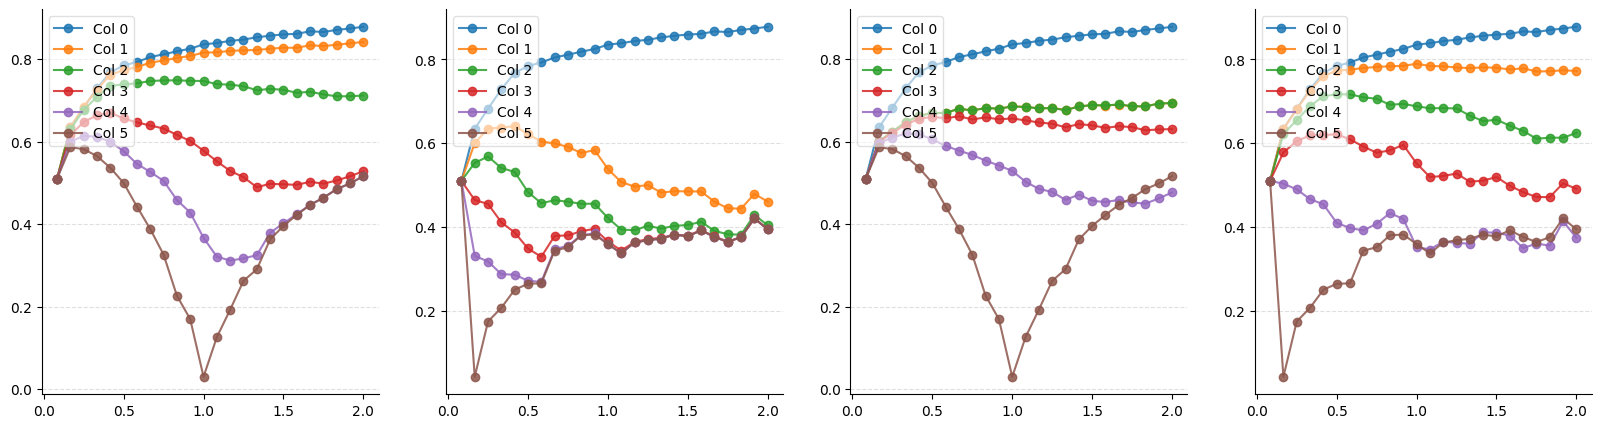

In [22]:
fig, ax = plt.subplots(1, len(mean_sharpe), figsize=(5*len(mean_sharpe), 5))
for j in range(len(mean_sharpe)):
    data = mean_sharpe[j][:, :]
    x = np.arange(1, data.shape[0] + 1) / 12
    for i, col in enumerate(data.T):
        ax[j].plot(x, col, linewidth=1.5, label=f'Col {i}', alpha=0.85, marker='o')

    ax[j].legend(framealpha=0.6, loc='upper left')
    ax[j].spines[['top', 'right']].set_visible(False)
    ax[j].grid(axis='y', linestyle='--', alpha=0.4)


In [ ]:
# # turn .mat files to .npy files
# import hdf5storage
# all_data = hdf5storage.loadmat('../03_data/ipca_data/all_data.mat')
# all_data['xret']
# charnames   = np.array([str(x[0][0]) for x in all_data['charnames'][0]], dtype=str)
# date        = all_data['date'][:, 0]
# xret        = all_data['xret']
# chars       = all_data['chars']
# np.save('../03_data/ipca_data/charnames.npy', charnames)
# np.save('../03_data/ipca_data/date.npy', date)
# np.save('../03_data/ipca_data/xret.npy', xret)
# np.save('../03_data/ipca_data/chars.npy', chars)

In [22]:
charnames   = np.load('../03_data/ipca_data/charnames.npy')
date        = np.load('../03_data/ipca_data/date.npy')
xret        = np.load('../03_data/ipca_data/xret.npy')
chars       = np.load('../03_data/ipca_data/chars.npy')

In [51]:
ew          = np.nanmean(xret, axis=0)
ew_alln     = np.mean(xret[np.all(~np.isnan(xret), axis=1), :], axis=0)

In [64]:
ew_df = pd.DataFrame({'ew':ew, 'ew_alln': ew_alln})
ew_df = ew_df.rolling(120).mean()*12/(ew_df.rolling(120).std() * np.sqrt(12))

In [65]:
from scipy import stats
tvalue, pvalue = stats.ttest_ind(ew_df['ew'], ew_df['ew_alln'], nan_policy='omit')

In [69]:
ew_df

,ew,ew_alln
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
594,0.526266,0.699149
595,0.543687,0.704015
596,0.545488,0.723694
597,0.545499,0.723148


In [68]:
tvalue

np.float64(-6.447328480813093)

In [42]:
np.mean(ew_alln)*12/(np.std(ew_alln) * np.sqrt(12))

np.float64(0.6354666267454857)